In [1]:
#!pip install pandas numpy matplotlib missingno
#%pip install scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import missingno as msno

import os
from pathlib import Path

#import sklearn.preprocessing

pd.options.display.max_rows=1000

import sys
import json
from IPython.display import display


def find_project_root(start: Path = Path.cwd()) -> Path:
    """Find the parent directory containing src/data.py."""
    for candidate in (start, *start.parents):
        if (candidate / "src" / "data.py").is_file():
            return candidate

    raise FileNotFoundError("Could not find src/data.py")


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
    


#from data import load_data, clean_prices, clean_stock_list, clean_financials
from config import ProjectConfig, ProjectPaths
from modeling import (
    build_model_pipeline
    ,chronological_split
    ,make_xy
    ,save_json
    ,select_recent_dates,
)
from features import (
    add_price_features
    ,assert_causal_feature_stability
    ,feature_missingness
    ,infer_feature_columns
    ,join_financials_asof
    ,join_stock_metadata
)

from modeling import save_json

config = ProjectConfig()
paths = ProjectPaths(PROJECT_ROOT)
paths.ensure_output_dirs

print("Project root:", PROJECT_ROOT)
print("Imported load_data successfully")

print("Imported libraries sucessfully! yay")

Project root: c:\Users\MY NGOC\Documents\MAU_TACAS_68803\DA631E_ArtificialIntelligenceForDataScience\Project_1_SupervisedLearning
Imported load_data successfully
Imported libraries sucessfully! yay


In [2]:
features_table = pd.read_parquet(path=paths.processed / "features_table.parquet")
numeric_features, categorical_features = infer_feature_columns(features_table)

## 1. Construct supervised chronological splits

In [3]:
splits, split_report = chronological_split(features_table=features_table, config=config)
train = splits['train']
valid = splits['validation']
test = splits['test']

display(split_report)
print("Purged from train: ", split_report.attrs['train_purged_dates'])
print("Purged from valid: ", split_report.attrs['validation_purged_dates'])

assert train["Date"].max() < valid["Date"].min()
assert valid["Date"].max() < test["Date"].min()
assert train["Target"].notna().all()
assert valid["Target"].notna().all()
assert test["Target"].notna().all()

,rows,dates,securities_codes,date_min,date_max,target_missing
split,,,,,,
train,1395521,731,1966,2017-01-04,2019-12-26,0
validation,476840,241,2000,2020-01-06,2020-12-28,0
test,452000,226,2000,2021-01-04,2021-12-03,0


Purged from train:  ['2019-12-27', '2019-12-30']
Purged from valid:  ['<generator object chronological_split.<locals>.<genexpr> at 0x0000021F9F441630>']


In [4]:
train.isna().sum()

RowId                                                0
Date                                                 0
SecuritiesCode                                       0
Open                                              3132
High                                              3132
Low                                               3132
Close                                             3132
Volume                                               0
AdjustmentFactor                                     0
ExpectedDividend                                     0
SupervisionFlag                                      0
Target                                               0
PartialOHLCFlag                                      0
NoTradeFlag                                          0
MarketWideNoTradeFlag                                0
StockSpecificNoTradeFlag                             0
AdjustmentEventFlag                                  0
HasExpectedDividend                                  0
LastTradeD

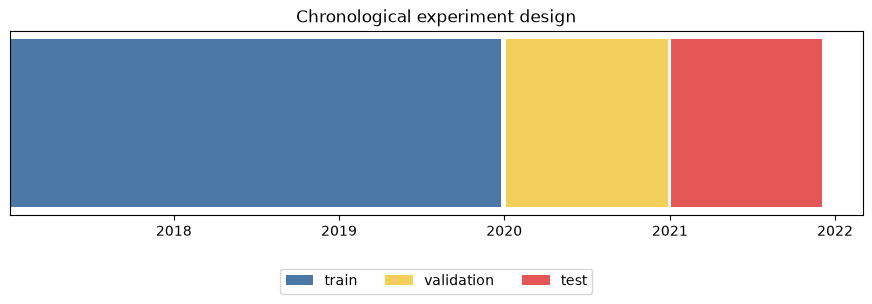

In [5]:
fig, ax = plt.subplots(figsize=(11, 2.4))
colors = {"train": "#4C78A8", "validation": "#F2CF5B", "test": "#E45756"}

for row, (name, frame) in enumerate(splits.items()):
    ax.barh(0, (frame["Date"].max() - frame["Date"].min()).days,
            left=frame["Date"].min(), height=0.5, color=colors[name], label=name)
ax.set_yticks([])
ax.set_title("Chronological experiment design")
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.25))
plt.show()

## Make X and y

In [6]:
X_train, y_train = make_xy(df=train, numeric_features=numeric_features, categorical_features=categorical_features)
X_valid, y_valid = make_xy(valid, numeric_features, categorical_features)

matrix_report = pd.DataFrame({
    "object": ["X_train", "y_train", "X_valid", "y_valid"],
    "rows": [len(X_train), len(y_train), len(X_valid), len(y_valid)],
    "columns": [X_train.shape[1], 1, X_valid.shape[1], 1],
})
display(matrix_report)
assert list(X_train.columns) == list(X_valid.columns)

,object,rows,columns
0,X_train,1395521,48
1,y_train,1395521,1
2,X_valid,476840,48
3,y_valid,476840,1


## fit_transform and transform

In [7]:
ridge_pipeline = build_model_pipeline(
    "ridge"
    ,numeric_features
    ,categorical_features
)
ridge_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default

## Small smoke test

Fit on the most recent 20 complete training dates and predict the first two
validation dates.

In [9]:
smoke_train = select_recent_dates(train, max_dates=20)
valid_dates = valid['Date'].drop_duplicates().sort_values().iloc[:2]
smoke_valid = valid.loc[valid['Date'].isin(valid_dates)]

X_smoke_train, y_smoke_train = make_xy(smoke_train, numeric_features, categorical_features)
X_smoke_valid, y_valid_smoke = make_xy(smoke_valid, numeric_features, categorical_features)

smoke_pipeline = build_model_pipeline("ridge", numeric_features, categorical_features)
smoke_pipeline.fit(X_smoke_train, y_smoke_train)
smoke_predictions = smoke_pipeline.predict(X_smoke_valid)

assert len(smoke_predictions) == len(smoke_valid)
assert np.isfinite(smoke_predictions).all()
print(f"Smoke test passed for {len(smoke_predictions):,} validation rows")

Smoke test passed for 3,932 validation rows


In [10]:
transformed_names = smoke_pipeline.named_steps['preprocess'].get_feature_names_out()
display(pd.Series(transformed_names, name="transformed_features").head(50).to_frame())
print(f"Raw input: {X_smoke_train.shape[1]}; transformed columns: {len(transformed_names)}")

,transformed_features
0,numeric__OpenToCloseReturn
1,numeric__HighLowRange
2,numeric__GapReturn
3,numeric__LogReturn1Day
4,numeric__Momentum5Days
5,numeric__Momentum20Days
6,numeric__Momentum60Days
7,numeric__Volatility20Days
8,numeric__Volatility60Days
9,numeric__VolatilityRatio20To60


Raw input: 48; transformed columns: 91


### save

In [11]:
experiment_audit = {
    "split_report": split_report.reset_index().to_dict(orient="records"),
    "train_purged_dates": split_report.attrs["train_purged_dates"],
    "validation_purged_dates": split_report.attrs["validation_purged_dates"],
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
}
save_json(experiment_audit, paths.reports / "experiment_audit.json")
print("Saved reports/experiment_audit.json")

Saved reports/experiment_audit.json
